In [1]:
import numpy as np
import pandas as pd
from src.processing import calculate_fitness, find_pareto_front
from src.visualization import display_pareto_front, display_fitness_landscape_with_pareto, dividir_plot_regioes, plota_fitness_landscape_com_equacoes

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['lines.linewidth'] = 0.5

# 1. Problema 1

### Definindo sistema de equações por fitness/objetivo

In [2]:
total_records = 1000000


#################################################################
############################################## Objetivo/fitness 1

equations1 = [

    # Funções gerais
    lambda x: 1.5 * np.sin(x/(total_records * 0.2)),     # eq0
    lambda x: np.cos(2 * x/(total_records * 0.1)),       # eq1
    lambda x: np.sin(4 * x/(total_records * 0.1)),       # eq2
    lambda x: 0.5 * np.sin(x/(total_records * 0.02)),    # eq3
    lambda x: 0.5 * np.sin(x/(total_records * 0.01)),    # eq4
    lambda x: 0.3 * np.sin(x/(total_records * 0.004)),   # eq5
    lambda x: 0.2 * np.sin(x/(total_records * 0.002)),   # eq6
    lambda x: 3-0.32599 + 0.1 * x/total_records,         # eq7
    
    lambda x: 0.3 * np.cos(1+x/(total_records * 0.001)), # eq8

    # Funções por região                                 # eq9
    lambda x: np.select(
        [
            x < 0.2 * total_records,
            x < 0.4 * total_records,
            x < 0.6 * total_records,
            x < 0.8 * total_records,
            x <=      total_records,
        ],
        [-0.8   + 1   * np.sin(2 * x/(total_records * 0.1)), # 0%  - 20%  (região 1)
         -1.0 - 1   * np.sin(4 * x/(total_records * 0.1)), # 20% - 40%  (região 2)
         -0.5,                                             # 40% - 60%  (região 3)
         -0.2 + 1   * np.sin(1 * x/(total_records * 0.1)), # 60% - 80%  (região 4)
          0.8 + 2.3 * np.cos(2 * x/(total_records * 0.1))  # 80% - 100% (região 5)
        ], default=0
    ),
]



#################################################################
############################################## Objetivo/fitness 2
equations2 = [


    # Funções gerais
    lambda x: 2.5 * np.cos(4+x/(total_records * 0.2)),    # eq0
    lambda x: 1.5 * (np.sin(2+x/(total_records * 0.2)) + 2) * (1-x/total_records),   # eq1
    lambda x: np.sin(1 + 2 * x/(total_records * 0.1)),    # eq2
    lambda x: np.sin(4 * x/(total_records * 0.1)),        # eq3
    lambda x: 0.5 * np.cos(1+x/(total_records * 0.03)),   # eq4
    lambda x: 0.5 * np.cos(1+x/(total_records * 0.02)),   # eq5
    lambda x: 0.4 * np.cos(1+x/(total_records * 0.006)),  # eq6
    lambda x: 0.2 * np.cos(1+x/(total_records * 0.005)),  # eq7
    lambda x: 0.2 * np.cos(1+x/(total_records * 0.0015)), # eq8
    lambda x: 0.1-0.156654 + 0.2 * x/total_records,       # eq9

    lambda x: 0.3 * np.sin(x/(total_records * 0.001)),    # eq10


    # Funções por região                                  # eq11
    lambda x: np.select(
        [
            x < 0.2 * total_records,
            x < 0.4 * total_records,
            x < 0.6 * total_records,
            x < 0.8 * total_records,
            x <=      total_records,
        ],
        [-0.7 + 1.5 * np.sin(-0.2 + x/(total_records * 0.1)),    # 0%  - 20%  (região 1)
         -1.2 + 2.3 * np.sin(1 * x/(total_records * 0.1)),       # 20% - 40%  (região 2)
          0.3 + 2.0 * np.cos(2.4 + 2 * x/(total_records * 0.1)), # 40% - 60%  (região 3)
         -0.5 + 3.5 * np.sin(-0.2 + x/(total_records * 0.1)),    # 60% - 80%  (região 4)
          2.8 + 1.5 * np.cos(2 + 2 * x/(total_records * 0.1))    # 80% - 100% (região 5)
        ], default=0
    ),
]

### Gerando dataframe com fitness landscape de 2 objetivos

In [3]:
# Criando dataframe com registros de 0 a 9.999.999
tamanho = len(str(total_records))-1
registros = np.arange(0, total_records, dtype=np.int32)
df = pd.DataFrame({'registro': registros})
print(f"Range: {registros[0]:,} até {registros[-1]:,}")

# Calculando fitness de forma matricial
df = calculate_fitness(equations1, equations2, df)
print(f"Colunas: {list(df.columns)}")

# últimos ajustes
df['fitness2'] = (0.77 * (df['fitness2'] - df['fitness2'].mean()) + df['fitness2'].mean())
df['fitness1'] = df['fitness1'].clip(0,7)
df['fitness2'] = df['fitness2'].clip(0,7)


# Salvando resultados
df.to_parquet('data/df_problema1.parquet')

Range: 0 até 999,999
Colunas: ['registro', 'fitness1_eq0', 'fitness1_eq1', 'fitness1_eq2', 'fitness1_eq3', 'fitness1_eq4', 'fitness1_eq5', 'fitness1_eq6', 'fitness1_eq7', 'fitness1_eq8', 'fitness1_eq9', 'fitness2_eq0', 'fitness2_eq1', 'fitness2_eq2', 'fitness2_eq3', 'fitness2_eq4', 'fitness2_eq5', 'fitness2_eq6', 'fitness2_eq7', 'fitness2_eq8', 'fitness2_eq9', 'fitness2_eq10', 'fitness2_eq11', 'fitness1', 'fitness2', 'fitness_full']


fitness1    3.002385
fitness2    3.000001
dtype: float64


/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


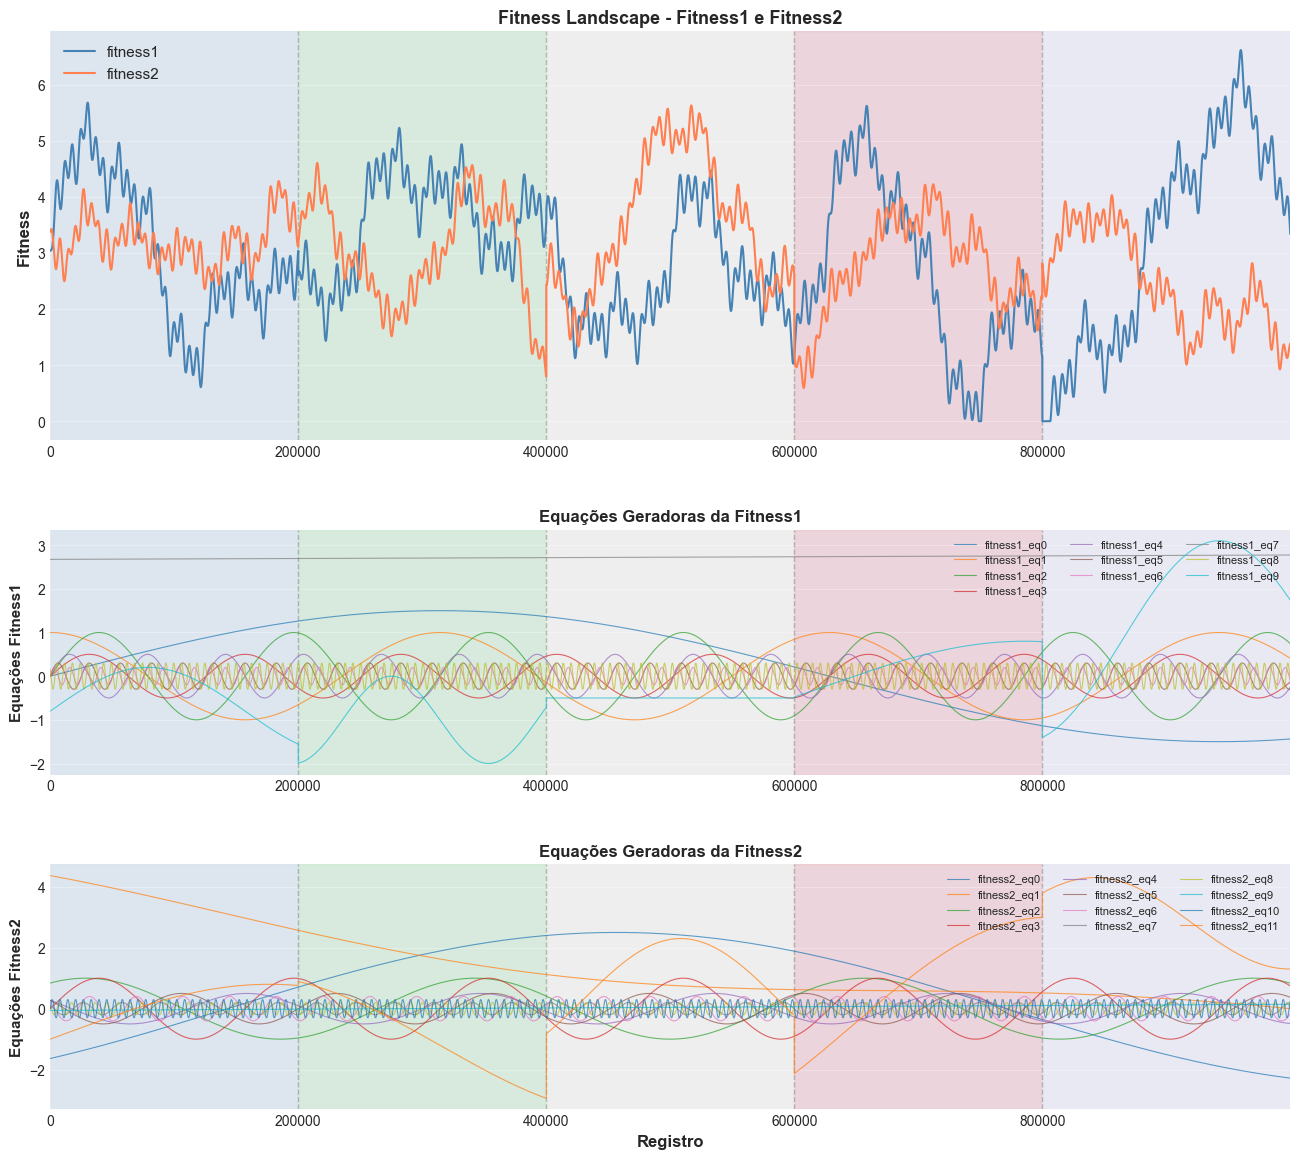

In [4]:
# Plota fitness landscape com equações geradoras em 3 subplots
print(df[['fitness1','fitness2']].mean())
plota_fitness_landscape_com_equacoes(df, n_regioes=5)

### Encontrando a fronteira de Pareto verdadeira

In [5]:
pareto_df = find_pareto_front(df)

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 10,344 pontos.
Isso representa 1.0344% do espaço de busca.


### Análise visual dos resultados

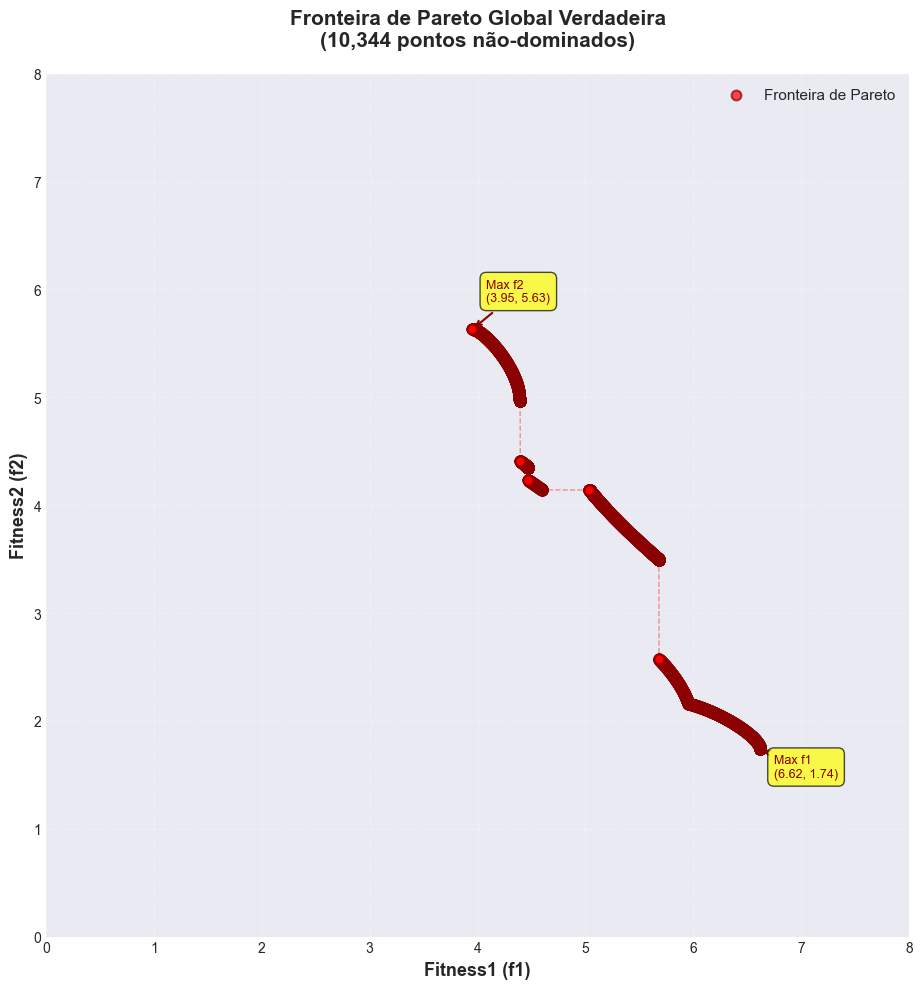


✅ Visualização concluída!


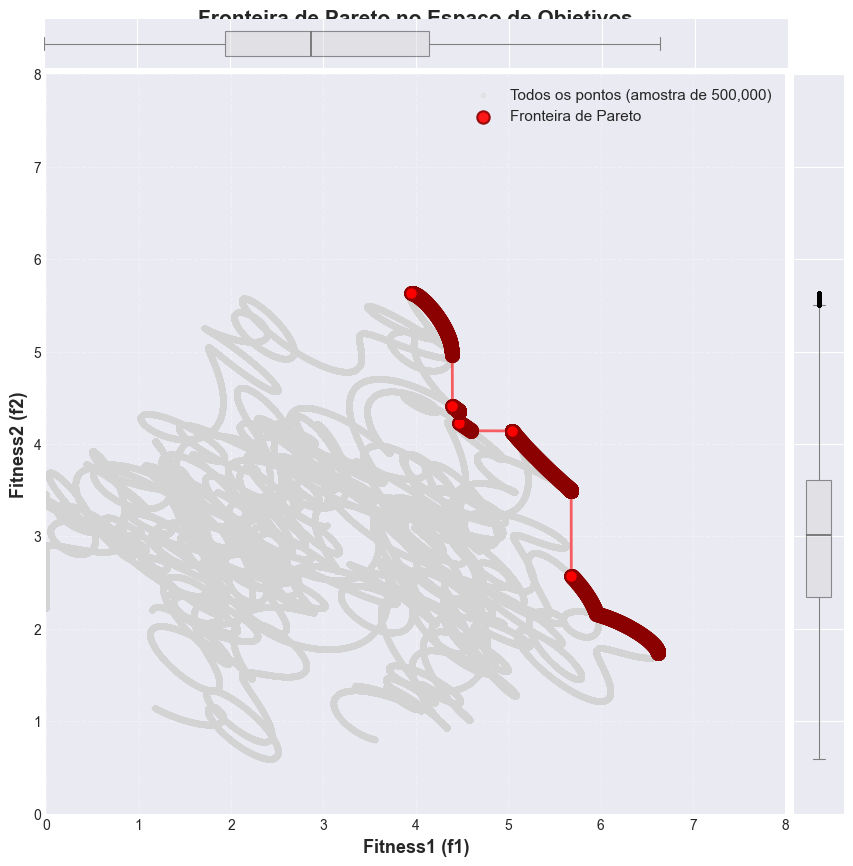

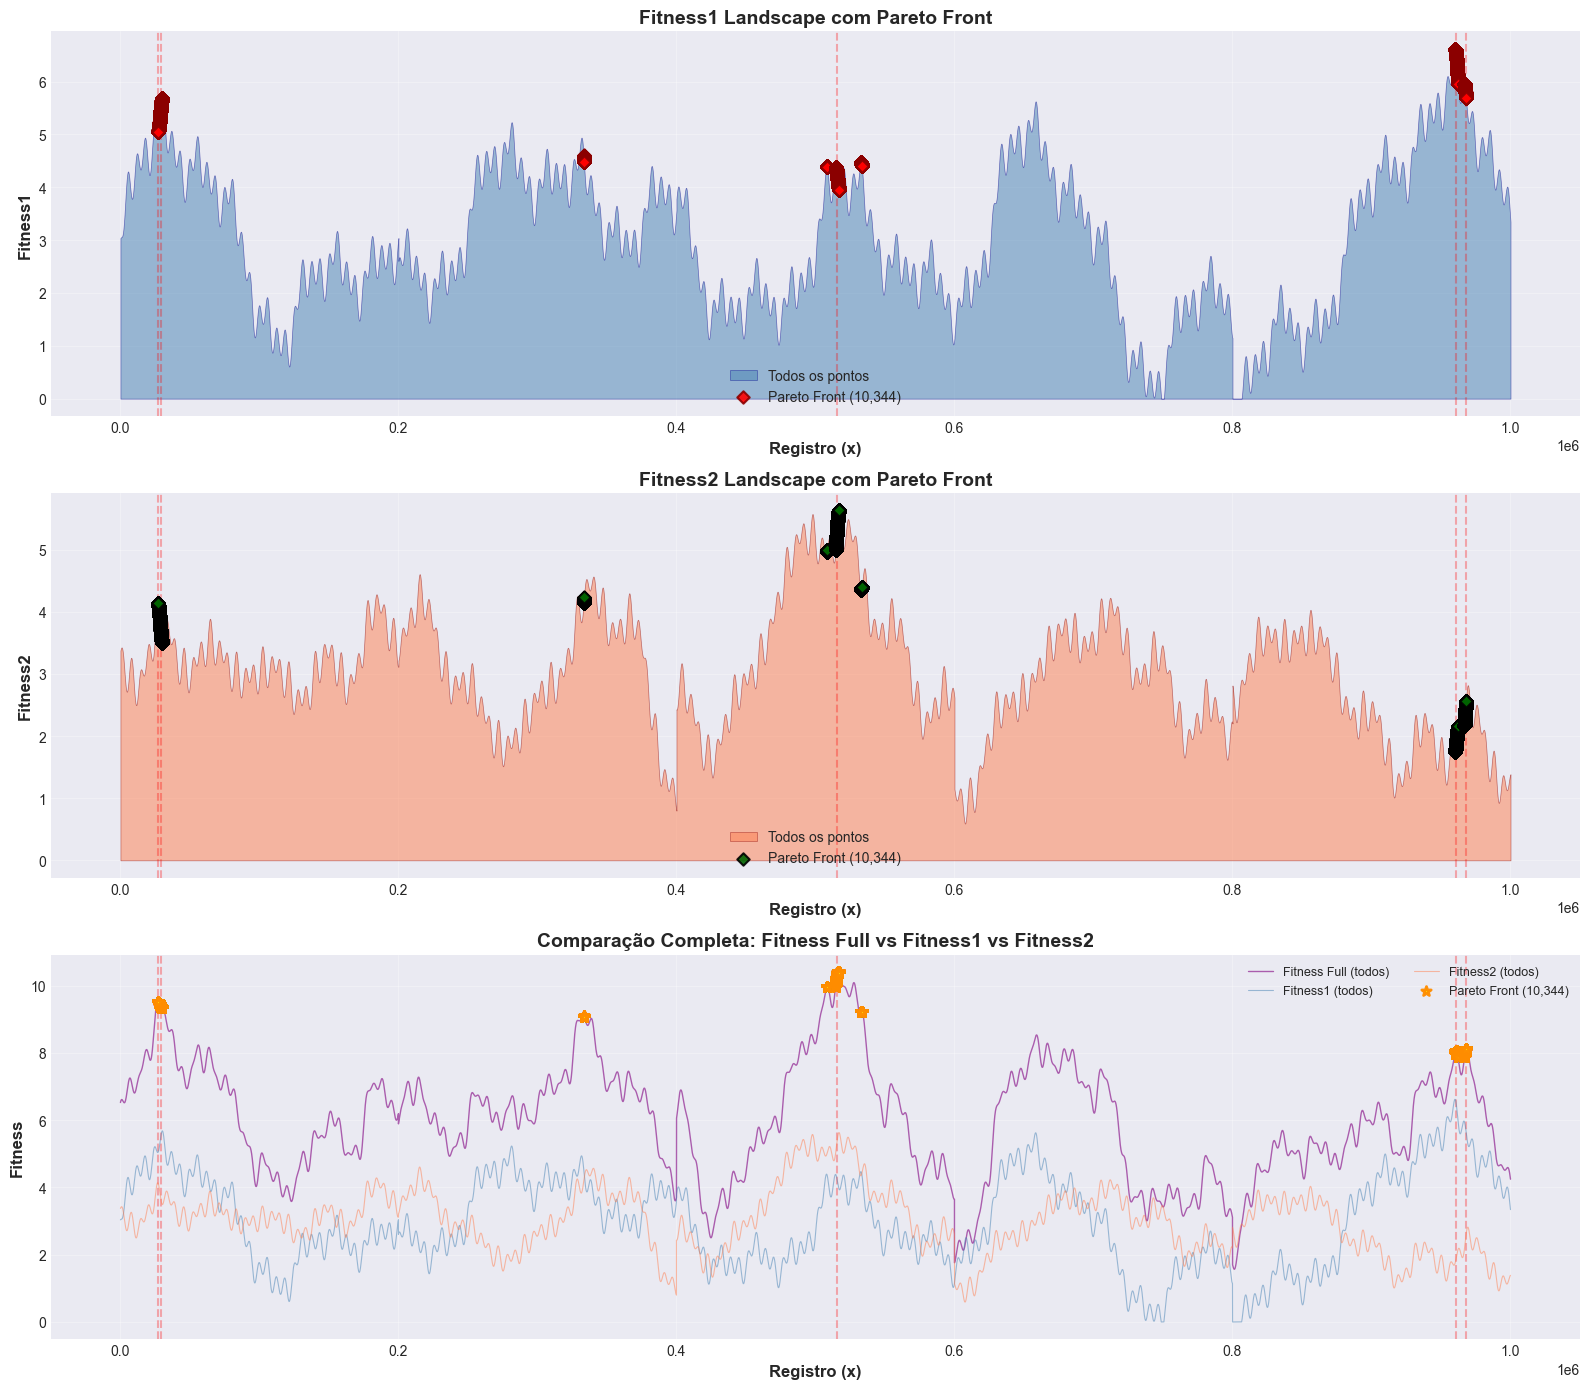

In [6]:
display_pareto_front(df, pareto_df)
display_fitness_landscape_with_pareto(df, pareto_df)

# 2. Problema 2

In [7]:
total_records = 1000000

# Parametrizar todas as equações por total_records
# Proporções calculadas com base em total_records = 10,000,000
equations1 = [
    lambda x: (x/(total_records * 0.05))**2 / 70,       # 500000 = total_records/20
    lambda x: 10 * np.cos(x/(total_records * 3)),       # 30000000 = total_records*3
    lambda x:  7 * np.cos(x/(total_records * 1)),       # 10000000 = total_records*1
    lambda x:  4 * np.cos(x/(total_records * 0.4)),     # 4000000 = total_records*0.4
    lambda x:  5 * np.cos(x/(total_records * 0.1)),     # 1000000 = total_records/10
    lambda x:  5 * np.cos(x/(total_records * 0.05)),    # 500000 = total_records/20
    lambda x:  4 * np.sin(x/(total_records * 0.01)),    # 100000 = total_records/100
    lambda x:  3 * np.cos(x/(total_records * 0.0025)),  # 25000 = total_records/400
    lambda x:  2 * np.cos(x/(total_records * 2 * 0.0004)),  # 4000 = total_records/2500
    lambda x:      np.sin(x/(total_records * 2 * 0.0002)),  # 2000 = total_records/5000
    lambda x: np.maximum(0, 3 * np.cos(2.3+ (x/(total_records * 0.001)))),  # 10000 = total_records/1000
    lambda x: np.maximum(0, 3 * np.sin(1  + (x/(total_records * 0.001)))),  # 10000 = total_records/1000
    lambda x: 5,
]

equations2 = [
#    lambda x: (x/(total_records * 0.1))**2 / 140,       # 500000 = total_records/20
    lambda x: (5**(-x/total_records))*3,
    lambda x: 10 * np.sin(x/(total_records * 3)),       # 30000000 = total_records*3
    lambda x:  7 * np.sin(x/(total_records * 1)),       # 10000000 = total_records*1
    lambda x:  2 * np.sin(x/(total_records * 0.4)),     # 4000000 = total_records*0.4
    lambda x:  2 * np.sin(x/(total_records * 0.2)),     # 2000000 = total_records/5
    lambda x:  2 * np.sin(x/(total_records * 0.1)),     # 1000000 = total_records/10
    lambda x:  2 * np.cos(x/(total_records * 0.03)),    # 300000 = total_records*0.03
    lambda x:  2 * np.cos(x/(total_records * 0.005)),   # 50000 = total_records/200
    lambda x:      np.sin(x/(total_records * 0.002)),   # 20000 = total_records/500
    lambda x:      np.cos(x/(total_records * 2 * 0.0008)),  # 8000 = total_records/1250
    lambda x: np.minimum(0, 3 * np.cos(2.3+ (x/(total_records * 0.001)))),  # 10000 = total_records/1000
    lambda x: np.minimum(0, 3 * np.sin(1  + (x/(total_records * 0.001)))),  # 10000 = total_records/1000
    lambda x: 5,
]

In [8]:
# Criando dataframe com registros de 0 a 9.999.999
tamanho = len(str(total_records))-1
registros = np.arange(0, total_records, dtype=np.int32)
df = pd.DataFrame({'registro': registros})
print(f"Range: {registros[0]:,} até {registros[-1]:,}")

# Calculando fitness de forma matricial
df = calculate_fitness(equations1, equations2, df)
mean_fitness1 = df['fitness1'].mean()
mean_fitness2 = df['fitness2'].mean()

df['fitness1'] = df['fitness1'] * 10/mean_fitness1
df['fitness2'] = df['fitness2'] * 10/mean_fitness2

# Salvando resultados
df.to_parquet('data/df_problema2.parquet')

Range: 0 até 999,999


fitness1    10.0
fitness2    10.0
dtype: float64


/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


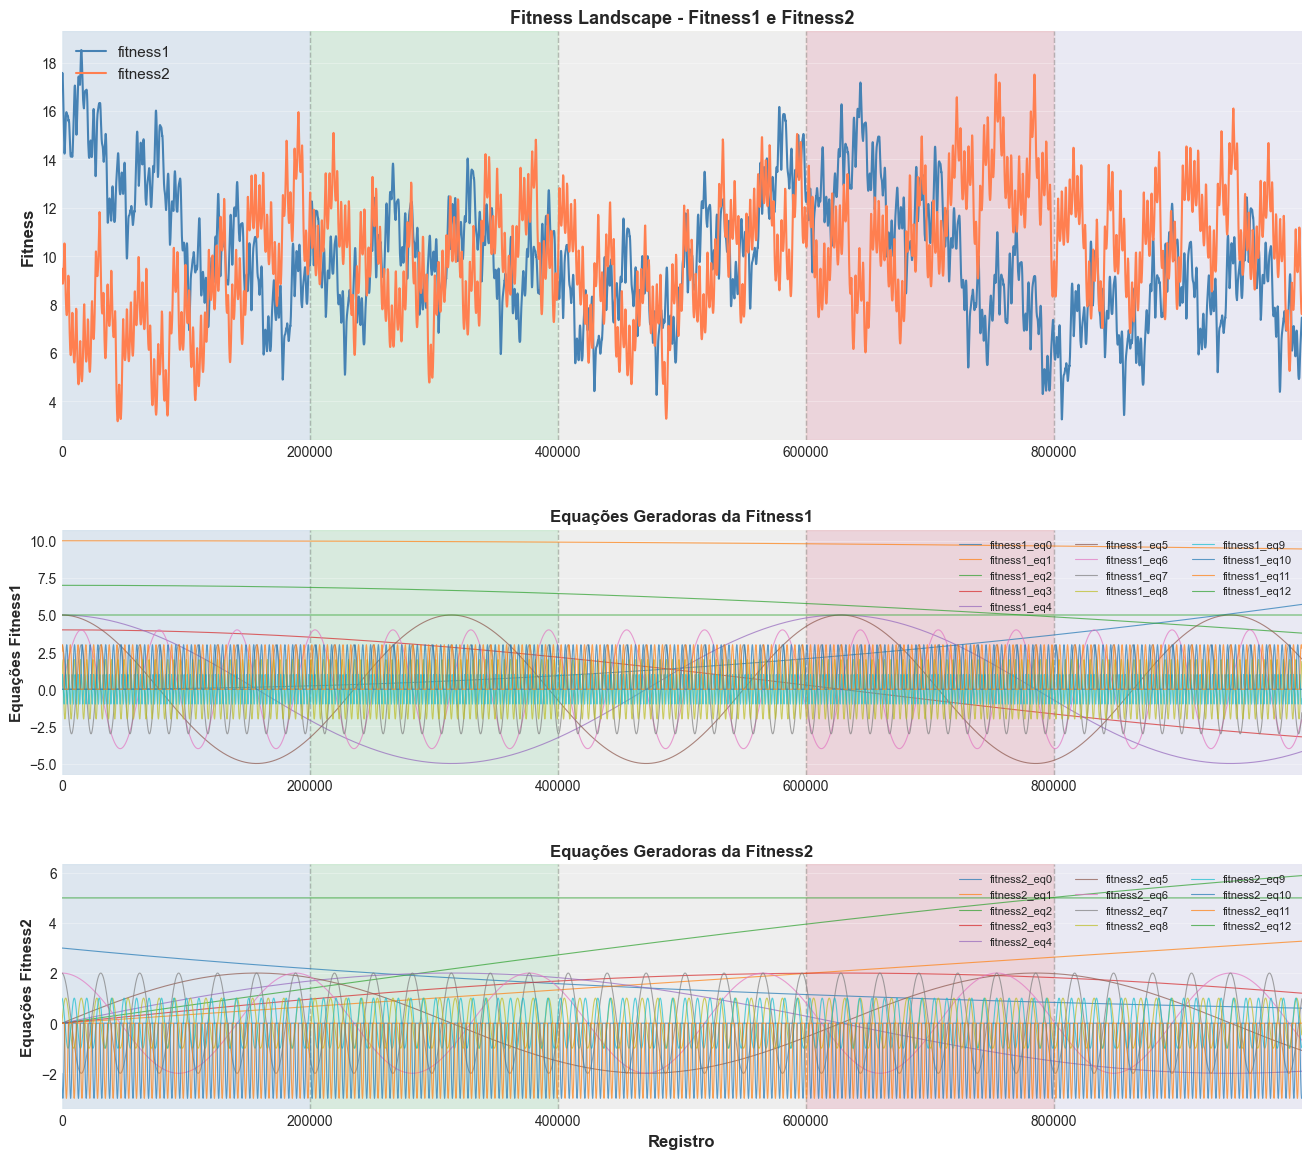

In [9]:
# Plota fitness landscape com equações geradoras em 3 subplots
print(df[['fitness1','fitness2']].mean())
plota_fitness_landscape_com_equacoes(df, n_regioes=5)

In [10]:
pareto_df = find_pareto_front(df)

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 4,416 pontos.
Isso representa 0.4416% do espaço de busca.


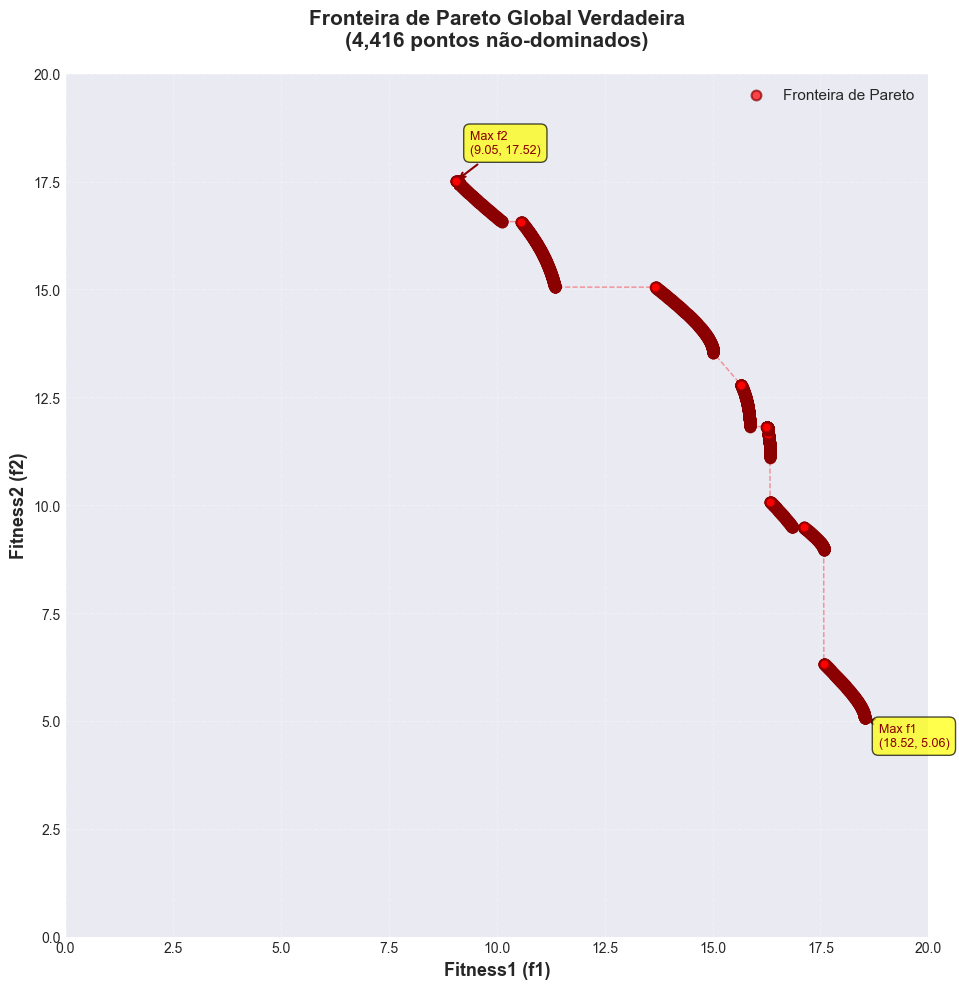


✅ Visualização concluída!


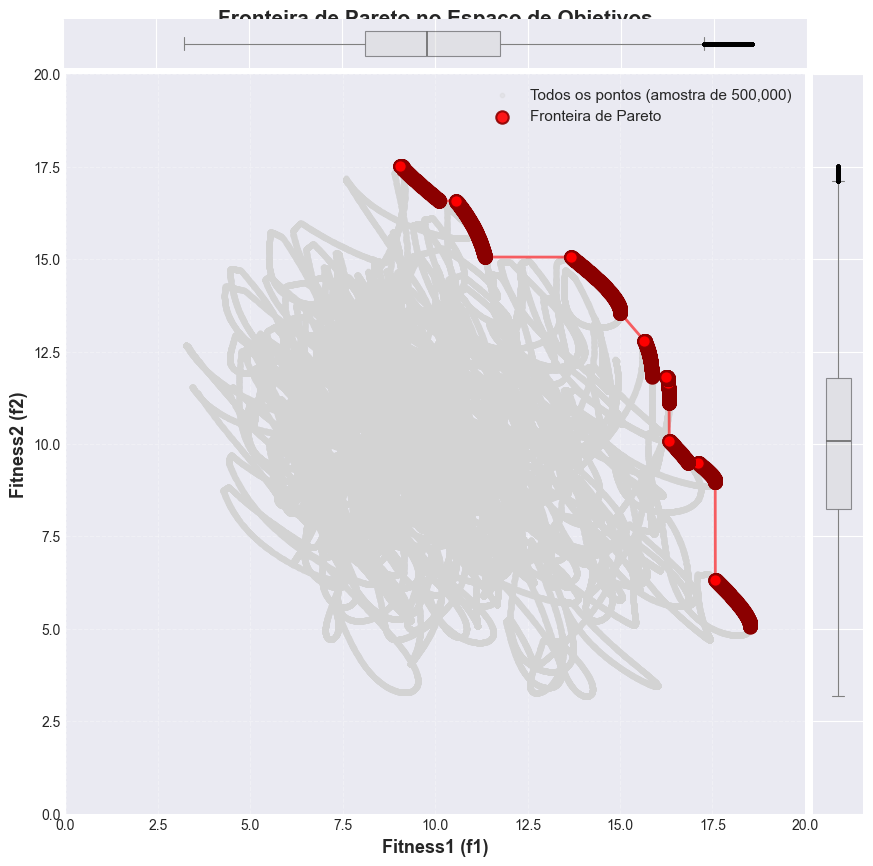

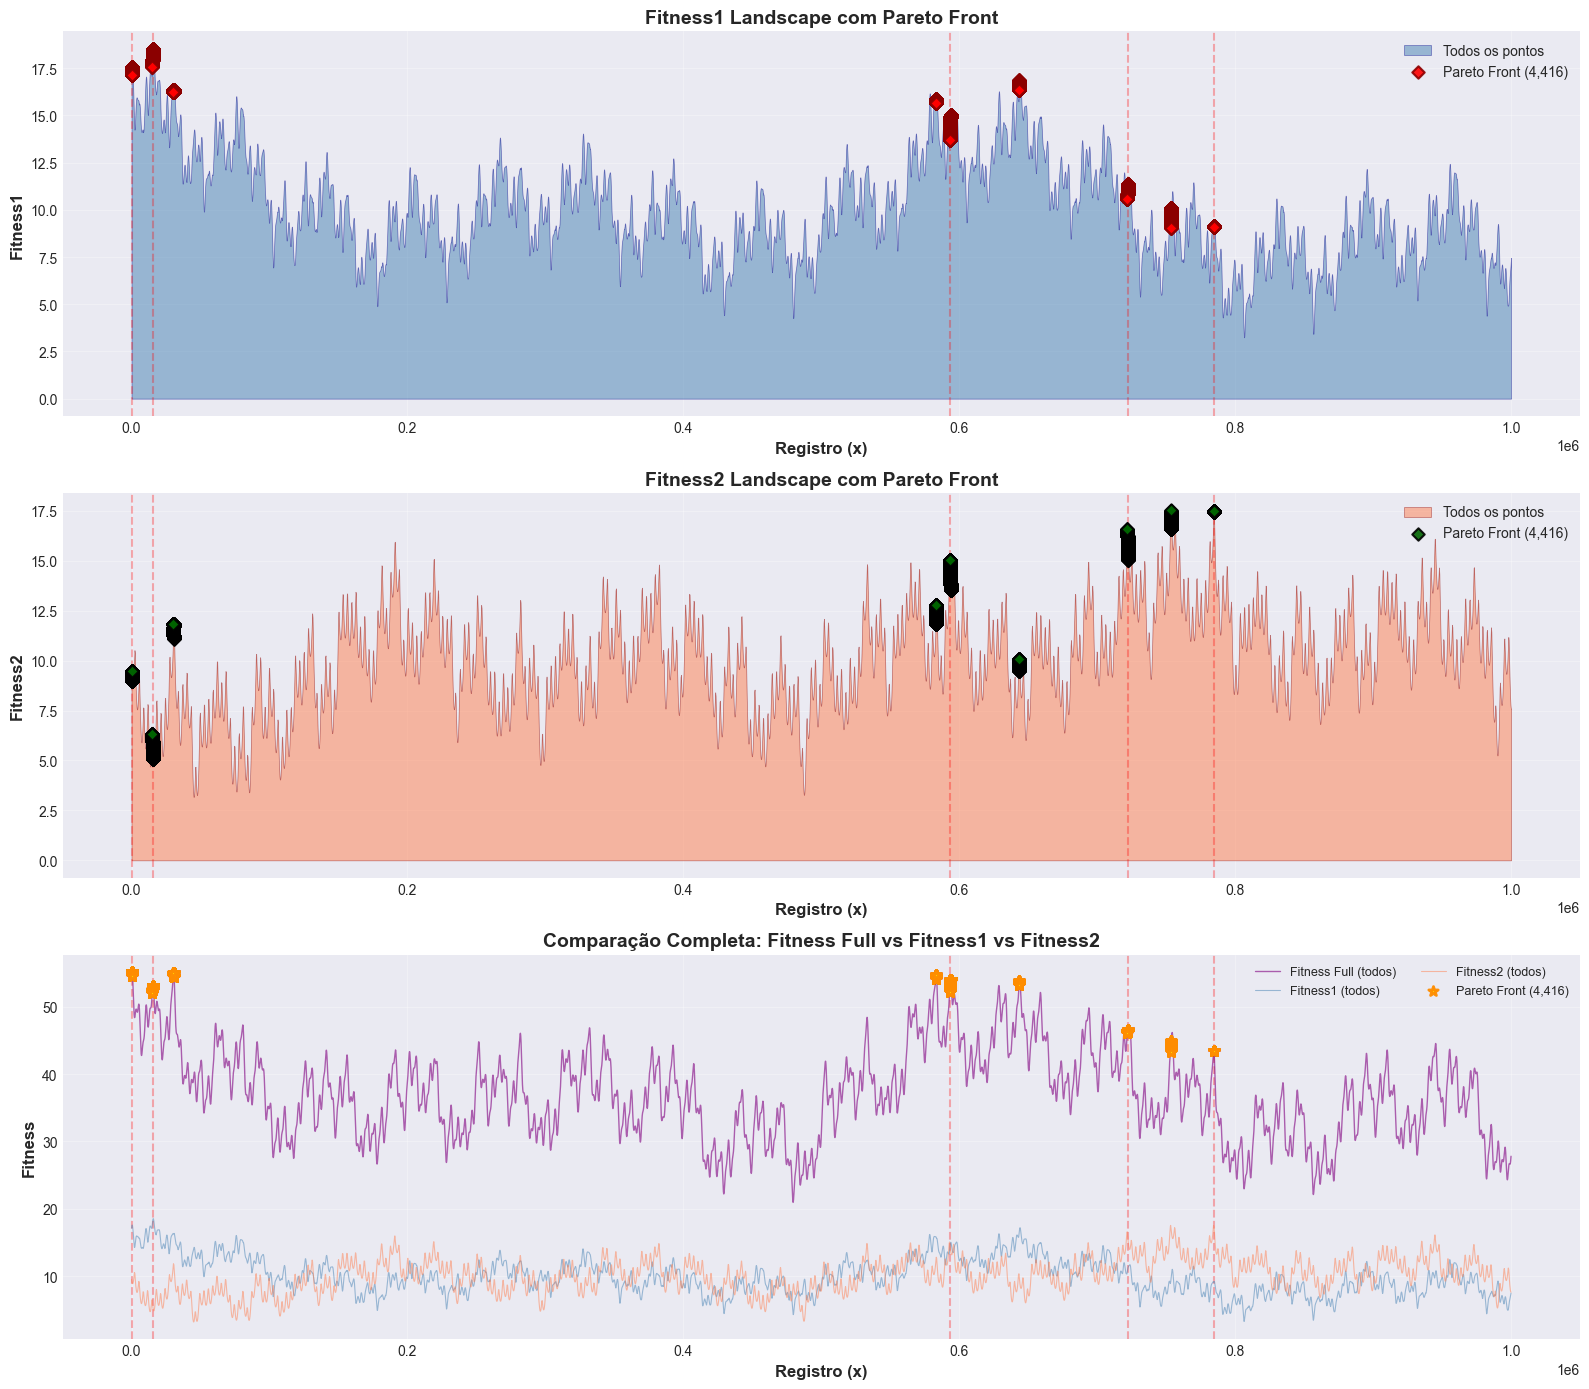

In [12]:
display_pareto_front(df, pareto_df)
display_fitness_landscape_with_pareto(df, pareto_df)